# Clasificación de Veredictos en "AmItheAsshole" con Transformers y Características Adicionales

## Propósito del Notebook

Este notebook tiene como objetivo clasificar los posts del subreddit "AmItheAsshole" (AITA) en uno de los cinco veredictos posibles: NTA (No Eres el Imbécil), YTA (Eres el Imbécil), ESH (Todos Son Imbéciles Aquí), NAH (No Hay Imbéciles Aquí), e INFO (Se Necesita Más Información).

Para lograr esto, se explorarán varias estrategias:
1.  Entrenamiento de la cabeza clasificadora de un modelo Transformer base (BERT) con el cuerpo del transformador congelado.
2.  Fine-tuning completo de diferentes arquitecturas Transformer (BERT, RoBERTa, XLM-RoBERTa).
3.  Desarrollo y entrenamiento de un modelo combinado que utiliza tanto las representaciones textuales de un Transformer como características numéricas extraídas de los posts (puntuación, número de comentarios, longitud del texto).

Se prestará especial atención al manejo del desbalanceo inherente en las clases de veredictos, utilizando técnicas como el sobremuestreo y la ponderación de clases en la función de pérdida. Finalmente, se realizará un análisis comparativo del rendimiento de los diferentes enfoques.

## Datasets Utilizados

-   **`df_submissions` y `df_comments`**: Datos crudos cargados desde la base de datos SQLite `AmItheAsshole.sqlite`.
-   **`df_merged`**: DataFrame que combina información de submissions y el veredicto mayoritario de los comentarios.
-   **`df_final`**: Versión filtrada y preprocesada de `df_merged` que contiene el texto del post, características numéricas (`score`, `num_comments`, `text_length`) y la etiqueta del veredicto (`label_id`).
-   **`train_df`, `val_df`, `test_df`**: Divisiones estratificadas de `df_final` para entrenamiento, validación y prueba. Las características numéricas en estos DataFrames están escaladas.


## Librerías Principales y Versiones

Se utilizarán las siguientes librerías principales. Las versiones se imprimirán en la primera celda de código.
- PyTorch
- Transformers
- Scikit-learn
- Pandas
- Imbalanced-learn
- NumPy
- tqdm

In [9]:
#=============== CELDA PRELIMINAR: INSTALACIONES Y CONFIGURACIÓN INICIAL ===============
!pip install -q torch transformers tqdm scikit-learn pandas numpy matplotlib seaborn nltk imbalanced-learn sentencepiece sacremoses
!mkdir -p saved_models_final # Directorio para guardar modelos

In [1]:

import sqlite3
import pandas as pd
from collections import Counter
import re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm

# ---------- Carga de datos ----------
conn = sqlite3.connect("data/AmItheAsshole.sqlite")
df_submissions = pd.read_sql_query(
    "SELECT submission_id, title, selftext, score FROM submission;", conn
)
df_comments = pd.read_sql_query(
    "SELECT submission_id, message FROM comment;", conn
)
conn.close()  # Cerrar conexión

# ---------- Extracción de veredictos ----------
verdict_pattern = re.compile(r'\b(NTA|YTA|ESH|NAH|INFO)\b', re.IGNORECASE)

def extract_verdict(msg):
    """Extrae el primer veredicto encontrado en el mensaje"""
    if pd.isna(msg):
        return None
    match = verdict_pattern.search(str(msg))
    return match.group(1).upper() if match else None

# Aplicar extracción y filtrar
df_comments['label'] = df_comments['message'].apply(extract_verdict)
df_comments_labeled = df_comments.dropna(subset=['label'])

# Obtener veredicto más común por submission
submission_verdicts = (df_comments_labeled
                      .groupby('submission_id')['label']
                      .apply(lambda x: Counter(x).most_common(1)[0][0])
                      .reset_index())


### 2. Ingeniería de características y división de datos  
1. Cuenta comentarios, combina título + self-text y calcula longitud.  
2. Filtra las cinco clases objetivo y les asigna IDs numéricos.  
3. Divide en **train / val / test** (80 / 10 / 10) de forma estratificada.  
4. Estandariza `score`, `num_comments` y `text_length` solo con estadísticas del *train*.  


In [2]:
# ---------- Feature Engineering ----------
# Número de comentarios por submission
comment_counts = (df_comments.groupby('submission_id')
                 .size()
                 .reset_index(name='num_comments'))

# Merge y creación de features
df_merged = (df_submissions
            .merge(submission_verdicts, on='submission_id')
            .merge(comment_counts, on='submission_id', how='left')
            .assign(
                num_comments=lambda x: x['num_comments'].fillna(0).astype(int),
                text=lambda x: x['title'].fillna('') + ' ' + x['selftext'].fillna(''),
                text_length=lambda x: x['text'].str.split().str.len()
            )
            [['submission_id', 'text', 'label', 'score', 'num_comments', 'text_length']])

# ---------- Preparación final ----------
TARGET_LABELS = ['NTA', 'YTA', 'ESH', 'NAH', 'INFO']
df_final = df_merged[df_merged['label'].isin(TARGET_LABELS)].copy()

# Mapeo de etiquetas
label2id = {lab: i for i, lab in enumerate(TARGET_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}
df_final['label_id'] = df_final['label'].map(label2id)

print(f"Distribución de clases:\n{df_final['label'].value_counts()}")

# ---------- División estratificada ----------
X = df_final.drop(['label', 'label_id'], axis=1)
y = df_final['label_id']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# ---------- Escalado de features numéricas ----------
num_features = ['score', 'num_comments', 'text_length']
scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_val[num_features] = scaler.transform(X_val[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
print(f"\nTamaños de conjuntos:")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
# Verificar distribución después del split
print(f"\nDistribución train:\n{pd.Series(y_train).map(id2label).value_counts()}")

Distribución de clases:
label
NTA     25027
YTA      5386
ESH       247
NAH       133
INFO       48
Name: count, dtype: int64

Tamaños de conjuntos:
Train: 24672 | Val: 3084 | Test: 3085

Distribución train:
label_id
NTA     20021
YTA      4309
ESH       198
NAH       106
INFO       38
Name: count, dtype: int64


## 3. Dataset, función de entrenamiento + validación y utilidades  
- **TextClassificationDataset**: tokeniza cada ejemplo y devuelve tensores listos para `DataLoader`.  
- **train_and_evaluate_model**: entrena (con opción de congelar la base BERT), valida con *early-stopping* y guarda checkpoints por mejor *val loss*.  
- Al final carga el mejor modelo y reporta métricas (accuracy, F1, matriz de confusión).  


In [3]:
# ---------- Cálculo de pesos para clases desbalanceadas ----------
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights)
print(f"\nPesos de clases balanceadas:")
for i, (label, weight) in enumerate(zip(TARGET_LABELS, class_weights)):
    print(f"{label}: {weight:.3f}")



Pesos de clases balanceadas:
NTA: 0.246
YTA: 1.145
ESH: 24.921
NAH: 46.551
INFO: 129.853


In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, classification_report
from tqdm.notebook import tqdm
from transformers import PreTrainedModel

# Crear directorio para checkpoints
os.makedirs("saved_models_final", exist_ok=True)


# ---------- CLASE DATASET MODIFICADA ----------
class TextClassificationDataset(Dataset):
    """Dataset optimizado para clasificación de texto con features numéricas opcionales."""
    def __init__(self, X_df, y_series, tokenizer, max_len=512,
                 text_col='text', num_feature_names=None): # X_df es el DataFrame, y_series son las etiquetas
        self.texts = X_df[text_col].astype(str).tolist()
        self.labels = y_series.tolist() if hasattr(y_series, 'tolist') else list(y_series)
        self.tokenizer = tokenizer
        self.max_len = max_len
        
        self.numerical_features_data = None
        if num_feature_names: # Lista de nombres de columnas para features numéricas
            # Asegurarse de que X_df contiene estas columnas
            self.numerical_features_data = torch.FloatTensor(X_df[num_feature_names].values)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        
        if 'token_type_ids' in encoding:
            item['token_type_ids'] = encoding['token_type_ids'].squeeze(0)
            
        if self.numerical_features_data is not None:
            # Clave cambiada a 'numerical_features' para consistencia
            item['numerical_features'] = self.numerical_features_data[idx]
            
        return item

class WeightedFocalLoss(nn.Module):
    """Focal Loss con pesos de clase para manejar desbalanceo extremo.
    Espera que class_weights_on_device ya esté en el dispositivo correcto (CPU/GPU).
    """
    def __init__(self, class_weights_on_device, alpha=1, gamma=2):
        super().__init__()
        # Guardar alpha y gamma
        self.alpha = alpha
        self.gamma = gamma
        # Crear la función de pérdida CrossEntropy interna una vez, con los pesos ya en el dispositivo
        # y reduction='none' para poder aplicar la modulación de Focal Loss.
        self.internal_ce_loss = nn.CrossEntropyLoss(weight=class_weights_on_device, reduction='none')
        
    def forward(self, inputs, targets):
        # 'inputs' y 'targets' deben estar en el mismo dispositivo que 'class_weights_on_device'
        # al momento de la creación de self.internal_ce_loss.
        ce_loss = self.internal_ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss) # Probabilidad del modelo para la clase correcta
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()



def freeze_bert_layers(model: PreTrainedModel, freeze_embeddings=True):
    """Congela capas de BERT manteniendo solo classifier activo."""
    frozen_params = 0
    total_params = 0
    
    for name, param in model.named_parameters():
        total_params += 1
        # Mantener activos: classifier, pooler (opcional)
        if any(layer in name for layer in ['classifier', 'pooler']):
            param.requires_grad = True
        else:
            param.requires_grad = False
            frozen_params += 1
    
    print(f"Congelados: {frozen_params}/{total_params} parámetros")
    return model

# ---------- FUNCIÓN DE ENTRENAMIENTO MODIFICADA Y GENERALIZADA ----------
def train_and_evaluate_model(
    model, model_name, train_loader, val_loader, test_loader,
    optimizer, loss_fn, device, id2label_map, # Renombrado id2label
    n_epochs=10, patience=3,
    freeze_backbone=False, use_focal_loss_print_only=False # Renombrado use_focal_loss
):
    """Función de entrenamiento optimizada con múltiples estrategias, ahora más general."""
    
    if freeze_backbone:
        model = freeze_bert_layers(model) # Asumiendo que model es un PreTrainedModel de HF
        print(f"[{model_name}] Entrenando solo capas de clasificación (o las no congeladas).")
    
    best_val_metric = 1e6
    patience_counter = 0
    best_model_path = None
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [], 
        'val_macro_f1': [], 'val_weighted_f1': []
    }
    
    print(f"\n{'='*50}")
    print(f"Entrenando: {model_name}")
    print(f"Épocas: {n_epochs} | Paciencia (basada en Val loss): {patience}")
    loss_type_str = "Focal" if use_focal_loss_print_only else "CrossEntropy"
    print(f"Loss: {loss_type_str} (con Class Weights si se pasó en `loss_fn`)")
    print(f"{'='*50}\n")
    
    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss_epoch = 0.0 # Renombrado para evitar confusión con train_loss de pbar
        
        pbar_train = tqdm(train_loader, desc=f"Época {epoch}/{n_epochs} [Train]")
        for batch in pbar_train:
            optimizer.zero_grad()
            
            labels = batch['labels'].to(device)
            # Preparar inputs para el modelo
            model_inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
            }
            if 'token_type_ids' in batch and batch['token_type_ids'] is not None:
                model_inputs['token_type_ids'] = batch['token_type_ids'].to(device)
            if 'numerical_features' in batch and batch['numerical_features'] is not None:
                model_inputs['numerical_features'] = batch['numerical_features'].to(device)

            outputs = model(**model_inputs)
            
            # Acceder a logits de forma flexible
            if isinstance(outputs, dict):
                current_logits = outputs['logits']
            elif hasattr(outputs, 'logits'):
                current_logits = outputs.logits
            else:
                # Si el modelo devuelve directamente los logits (poco común para HF)
                # O si es un modelo que devuelve la pérdida y los logits por separado en un tuple
                # Esto necesitaría una lógica más compleja o una convención más estricta.
                # Por ahora, asumimos dict o .logits
                raise ValueError("El modelo no devolvió 'logits' en un formato esperado.")

            loss = loss_fn(current_logits, labels)
            train_loss_epoch += loss.item()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            pbar_train.set_postfix({'train_loss': f"{loss.item():.4f}"})
        
        avg_train_loss = train_loss_epoch / len(train_loader)
        
        model.eval()
        val_loss_epoch = 0.0
        val_preds, val_true = [], []
        
        pbar_val = tqdm(val_loader, desc="Validación", leave=False)
        with torch.no_grad():
            for batch in pbar_val:
                labels = batch['labels'].to(device)
                model_inputs = {
                    'input_ids': batch['input_ids'].to(device),
                    'attention_mask': batch['attention_mask'].to(device),
                }
                if 'token_type_ids' in batch and batch['token_type_ids'] is not None:
                    model_inputs['token_type_ids'] = batch['token_type_ids'].to(device)
                if 'numerical_features' in batch and batch['numerical_features'] is not None:
                    model_inputs['numerical_features'] = batch['numerical_features'].to(device)

                outputs = model(**model_inputs)

                if isinstance(outputs, dict):
                    current_logits = outputs['logits']
                elif hasattr(outputs, 'logits'):
                    current_logits = outputs.logits
                else:
                    raise ValueError("El modelo no devolvió 'logits' en un formato esperado durante la validación.")

                loss = loss_fn(current_logits, labels) # Usar la misma loss_fn para consistencia
                val_loss_epoch += loss.item()
                
                preds = torch.argmax(current_logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        avg_val_loss = val_loss_epoch / len(val_loader)
        val_macro_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
        val_weighted_f1 = f1_score(val_true, val_preds, average='weighted', zero_division=0)
        
        history['epoch'].append(epoch)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_macro_f1'].append(val_macro_f1)
        history['val_weighted_f1'].append(val_weighted_f1)
        
        print(f"Época {epoch:2d}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1-Macro: {val_macro_f1:.4f}")
        
        if avg_val_loss < best_val_metric:
            best_val_metric = avg_val_loss
            patience_counter = 0
            
            safe_name = model_name.replace("/", "_").replace("-", "_")
            best_model_path = os.path.join("saved_models_final", f"{safe_name}_best.pt") # Usar os.path.join
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'best_val_metric': best_val_metric, # Guardar la métrica relevante
                'optimizer_state_dict': optimizer.state_dict(), # Opcional, pero útil
                'history': history # Guardar historial parcial
            }, best_model_path)
            print(f"✅ Nuevo mejor Val loss: {best_val_metric:.4f} → Guardado en {best_model_path}")
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"🛑 Early stopping después de {epoch} épocas (Val loss no mejoró por {patience} épocas).")
            break
            
    final_test_metrics = {} # Inicializar por si no hay best_model_path
    if best_model_path and os.path.exists(best_model_path):
        print(f"\n📂 Cargando mejor modelo desde: {best_model_path} (Val loss: {best_val_metric:.4f})")
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        # Cargar historial completo del mejor checkpoint
        history = checkpoint.get('history', history) # Usar historial guardado si existe
    else:
        print("\n⚠️ No se encontró el mejor modelo guardado o no se alcanzó a guardar. Usando el último estado del modelo para evaluación.")

    print("\nEvaluando en el conjunto de Test con el modelo seleccionado...")
    final_test_metrics = evaluate_model(model, test_loader, device, id2label_map, model_tag=f"{model_name} (Test)")
    
    return model, history, best_model_path, final_test_metrics



# ---------- FUNCIÓN DE EVALUACIÓN MODIFICADA (basada en la del usuario) ----------
def evaluate_model(model, dataloader, device, id2label_map, # Renombrado id2label a id2label_map
                   model_tag="Model", show_cm=True): # Renombrado tag a model_tag
    """Evalúa `model` en `dataloader` y devuelve un dict con métricas."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {model_tag}"):
            labels = batch['labels'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch.get('token_type_ids')
            num_feats = batch.get('numerical_features')

            model_inputs = {
                'input_ids': input_ids,
                'attention_mask': attention_mask
            }
            if token_type_ids is not None:
                model_inputs['token_type_ids'] = token_type_ids.to(device)
            if num_feats is not None:
                model_inputs['numerical_features'] = num_feats.to(device)
            
            # El modelo puede devolver un dict o un objeto ModelOutput
            outputs = model(**model_inputs)
            
            # Acceder a logits de forma flexible
            if isinstance(outputs, dict):
                logits = outputs['logits']
            elif hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                raise ValueError("El modelo no devolvió 'logits' en un formato esperado.")

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"\n📋 {model_tag} — Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

    # Usar id2label_map que es un dict {id: label_str}
    # Obtener nombres de etiquetas ordenados por ID para el reporte y la matriz
    sorted_label_ids = sorted(id2label_map.keys())
    target_names = [id2label_map[i] for i in sorted_label_ids]
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                labels=sorted_label_ids, # Pasar los IDs de las etiquetas
                                target_names=target_names,
                                zero_division=0))
    if show_cm:
        cm = confusion_matrix(all_labels, all_preds, labels=sorted_label_ids)
        plt.figure(figsize=(8, 6)) # Ajustado tamaño
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names)
        plt.xlabel("Predicción")
        plt.ylabel("Verdadero")
        plt.title(f"Matriz de Confusión – {model_tag}")
        plt.tight_layout()
        plt.show()

    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'predictions': all_preds, # Renombrado para claridad
        'true_labels': all_labels # Renombrado para claridad
    }


2025-05-27 04:00:36.899835: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-27 04:00:36.914440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748336436.934286   23303 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748336436.938783   23303 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748336436.949570   23303 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### 3.2  ·  Experimento 1 — BERT congelado  
Define hiperparámetros, crea DataLoaders y entrena **solo la cabeza** de clasificación.  

In [5]:
# ---------- Parámetros globales ----------
MAX_SEQ_LEN = 256
BATCH_SIZE = 32  # Reducido para RTX 4090 con secuencias largas
LEARNING_RATE = 1e-5
MAX_EPOCHS = 15
PATIENCE_EARLY_STOPPING = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# ── Inicializar contenedores para resultados ──
experiment_results = {}
experiment_histories = {}
experiment_model_paths = {}

Usando dispositivo: cuda



EXPERIMENTO 1: BERT BASE CONGELADO (Solo Clasificador)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizer cargado: bert-base-uncased
Dataset sizes: Train=24672, Val=3084, Test=3085
Modelo cargado en cuda
Parámetros totales: 109,486,085

Arquitectura del clasificador:
Clasificador: Linear(in_features=768, out_features=5, bias=True)
Parámetros a optimizar: 109,486,085
Loss function: CrossEntropyLoss con class weights
Class weights: tensor([  0.2465,   1.1451,  24.9212,  46.5509, 129.8526])

Iniciando entrenamiento...
Configuración:
  - Modelo: bert-base-uncased
  - Batch size: 32
  - Learning rate: 1e-05
  - Max epochs: 15
  - Patience: 3
  - Backbone: CONGELADO
Congelados: 197/201 parámetros
[bert-base-uncased_frozen] Entrenando solo capas de clasificación (o las no congeladas).

Entrenando: bert-base-uncased_frozen
Épocas: 15 | Paciencia (basada en Val loss): 3
Loss: CrossEntropy (con Class Weights si se pasó en `loss_fn`)



Época 1/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

...

Época 5/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

Época  5: Train Loss: 1.5487 | Val Loss: 1.6679 | Val F1-Macro: 0.1873
🛑 Early stopping después de 5 épocas (Val loss no mejoró por 3 épocas).

📂 Cargando mejor modelo desde: saved_models_final/bert_base_uncased_frozen_best.pt (Val loss: 1.6532)

Evaluando en el conjunto de Test con el modelo seleccionado...


Evaluating bert-base-uncased_frozen (Test):   0%|          | 0/97 [00:00<?, ?it/s]


📋 bert-base-uncased_frozen (Test) — Accuracy: 0.3712 | Macro-F1: 0.1477 | Weighted-F1: 0.3992

Classification Report:
              precision    recall  f1-score   support

         NTA       0.87      0.28      0.42      2503
         YTA       0.19      0.82      0.31       539
         ESH       0.00      0.00      0.00        25
         NAH       0.00      0.00      0.00        13
        INFO       0.00      0.00      0.00         5

    accuracy                           0.37      3085
   macro avg       0.21      0.22      0.15      3085
weighted avg       0.74      0.37      0.40      3085



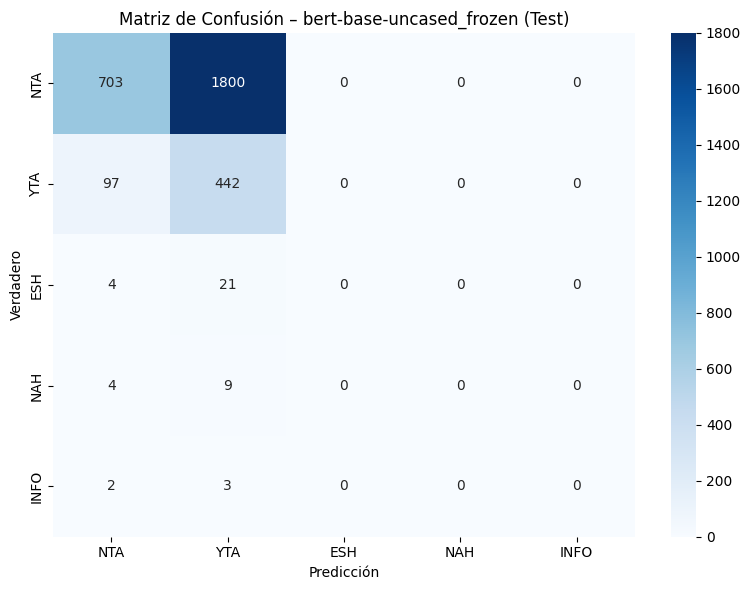


RESUMEN EXPERIMENTO 1
Modelo: bert-base-uncased_frozen
Mejor checkpoint: saved_models_final/bert_base_uncased_frozen_best.pt
Métricas finales:
  accuracy: 0.3712
  macro_f1: 0.1477
  weighted_f1: 0.3992

Análisis detallado por clase:
Recordatorio - Distribución original:
  NTA: 20021 ejemplos
  YTA: 4309 ejemplos
  ESH: 198 ejemplos
  NAH: 106 ejemplos
  INFO: 38 ejemplos

Verificación final - Parámetros entrenables:
  ✅ bert.pooler.dense.weight
  ✅ bert.pooler.dense.bias
  ✅ classifier.weight
  ✅ classifier.bias

Resumen congelamiento:
  Parámetros entrenables: 4
  Parámetros congelados: 197
  Total: 201

🎉 Experimento 1 completado exitosamente!
Resultados guardados en: experiment_results['bert-base-uncased_frozen']


In [6]:

print(f"\n{'='*70}")
print("EXPERIMENTO 1: BERT BASE CONGELADO (Solo Clasificador)")
print(f"{'='*70}")

#=============== EXPERIMENTO 1 - BERT CONGELADO ===============
model_name = "bert-base-uncased"
experiment_id = f"{model_name}_frozen"

# --- Tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(model_name)
print(f"Tokenizer cargado: {model_name}")

# --- Datasets ---
# Usar los datos ya preparados (X_train, y_train, etc.)
train_ds = TextClassificationDataset(X_train, y_train, tokenizer, MAX_SEQ_LEN)
val_ds = TextClassificationDataset(X_val, y_val, tokenizer, MAX_SEQ_LEN)
test_ds = TextClassificationDataset(X_test, y_test, tokenizer, MAX_SEQ_LEN)

print(f"Dataset sizes: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")

# --- DataLoaders ---
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- Modelo ---
config = AutoConfig.from_pretrained(model_name, num_labels=len(TARGET_LABELS))
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    config=config,
    ignore_mismatched_sizes=True
).to(device)

print(f"Modelo cargado en {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")

# --- Verificar arquitectura del clasificador ---
print(f"\nArquitectura del clasificador:")
if hasattr(model, 'classifier'):
    print(f"Clasificador: {model.classifier}")
elif hasattr(model, 'bert') and hasattr(model, 'classifier'):
    print(f"BERT + Clasificador: {model.classifier}")
else:
    print("Estructura del modelo:")
    for name, module in model.named_children():
        print(f"  {name}: {type(module)}")

# --- Optimizador ---
# Solo optimizar parámetros que se van a entrenar (clasificador)
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=0.01)

print(f"Parámetros a optimizar: {sum(p.numel() for p in trainable_params):,}")

# --- Loss Function con class weights ---
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

# Alternativa: usar Focal Loss para mejor manejo del desbalanceo
#loss_fn = WeightedFocalLoss(class_weights_tensor.to(device), alpha=1, gamma=2)

print(f"Loss function: CrossEntropyLoss con class weights")
print(f"Class weights: {class_weights_tensor}")

# --- Entrenamiento + evaluación ---
print(f"\nIniciando entrenamiento...")
print(f"Configuración:")
print(f"  - Modelo: {model_name}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Max epochs: {MAX_EPOCHS}")
print(f"  - Patience: {PATIENCE_EARLY_STOPPING}")
print(f"  - Backbone: CONGELADO")

model_trained, history, best_path, metrics = train_and_evaluate_model(
    model=model,
    model_name=experiment_id,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    id2label_map=id2label,
    n_epochs=MAX_EPOCHS,
    patience=PATIENCE_EARLY_STOPPING,
    freeze_backbone=True,  # Usar la función de congelamiento optimizada
    use_focal_loss_print_only=False
)

# --- Guardar resultados ---
experiment_results[experiment_id] = metrics
experiment_histories[experiment_id] = history
experiment_model_paths[experiment_id] = best_path

print(f"\n{'='*70}")
print("RESUMEN EXPERIMENTO 1")
print(f"{'='*70}")
print(f"Modelo: {experiment_id}")
print(f"Mejor checkpoint: {best_path}")
print(f"Métricas finales:")
for metric, value in metrics.items():
    if isinstance(value, (int, float)):
        print(f"  {metric}: {value:.4f}")

# --- Análisis de resultados por clase ---
print(f"\nAnálisis detallado por clase:")
print(f"Recordatorio - Distribución original:")
for i, label in enumerate(TARGET_LABELS):
    count = sum(1 for y in y_train if y == i)
    print(f"  {label}: {count} ejemplos")

# --- Verificar que el modelo está correctamente congelado ---
print(f"\nVerificación final - Parámetros entrenables:")
trainable_count = 0
frozen_count = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_count += 1
        print(f"  ✅ {name}")
    else:
        frozen_count += 1

print(f"\nResumen congelamiento:")
print(f"  Parámetros entrenables: {trainable_count}")
print(f"  Parámetros congelados: {frozen_count}")
print(f"  Total: {trainable_count + frozen_count}")

# --- Limpiar memoria GPU ---
torch.cuda.empty_cache()

print(f"\n🎉 Experimento 1 completado exitosamente!")
print(f"Resultados guardados en: experiment_results['{experiment_id}']")

## 3.3 · Experimento 2 – Fine-tuning completo  
Para cada modelo (`bert-base-uncased`, `roberta-base`, `xlm-roberta-base`) se:  
1. Crea un tokenizer y los `DataLoader` correspondientes.  
2. Carga el modelo con la cabeza adecuada y deja **todas** las capas entrenables.  
3. Define optimizador + pérdida ponderada.  
4. Entrena con *early-stopping*, evalúa en test y guarda métricas / checkpoints.  



EXPERIMENTO 2: FINE-TUNING COMPLETO DE MODELOS BERT

▶ Iniciando Fine-tuning para: bert-base-uncased
Experiment ID: bert-base-uncased_finetuned
Cargando tokenizer: bert-base-uncased...
Tokenizer 'bert-base-uncased' cargado.
Creando datasets...
Tamaños de Datasets: Train=24672, Val=3084, Test=3085
Creando DataLoaders...
DataLoaders creados.
Cargando modelo preentrenado: bert-base-uncased...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo 'bert-base-uncased' cargado en cuda.
Parámetros totales: 109,486,085
Optimizador AdamW configurado con LR=1e-05, Weight Decay=0.01.
Parámetros a optimizar: 109,486,085
Loss function: CrossEntropyLoss con class weights
Class weights (tensor): tensor([  0.2465,   1.1451,  24.9212,  46.5509, 129.8526])

Iniciando entrenamiento para bert-base-uncased...
Configuración:
  - Modelo: bert-base-uncased
  - Batch size: 32
  - Learning rate: 1e-05
  - Max epochs: 15
  - Patience: 3
  - Backbone: FINE-TUNING COMPLETO

Entrenando: bert-base-uncased_finetuned
Épocas: 15 | Paciencia (basada en Val loss): 3
Loss: CrossEntropy (con Class Weights si se pasó en `loss_fn`)



Época 1/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

...

Época 5/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

Época  5: Train Loss: 0.9280 | Val Loss: 1.6910 | Val F1-Macro: 0.2415
🛑 Early stopping después de 5 épocas (Val loss no mejoró por 3 épocas).

📂 Cargando mejor modelo desde: saved_models_final/bert_base_uncased_finetuned_best.pt (Val loss: 1.4452)

Evaluando en el conjunto de Test con el modelo seleccionado...


Evaluating bert-base-uncased_finetuned (Test):   0%|          | 0/97 [00:00<?, ?it/s]


📋 bert-base-uncased_finetuned (Test) — Accuracy: 0.5423 | Macro-F1: 0.2224 | Weighted-F1: 0.5881

Classification Report:
              precision    recall  f1-score   support

         NTA       0.92      0.49      0.64      2503
         YTA       0.25      0.81      0.39       539
         ESH       0.00      0.00      0.00        25
         NAH       0.00      0.00      0.00        13
        INFO       0.05      0.20      0.08         5

    accuracy                           0.54      3085
   macro avg       0.24      0.30      0.22      3085
weighted avg       0.79      0.54      0.59      3085



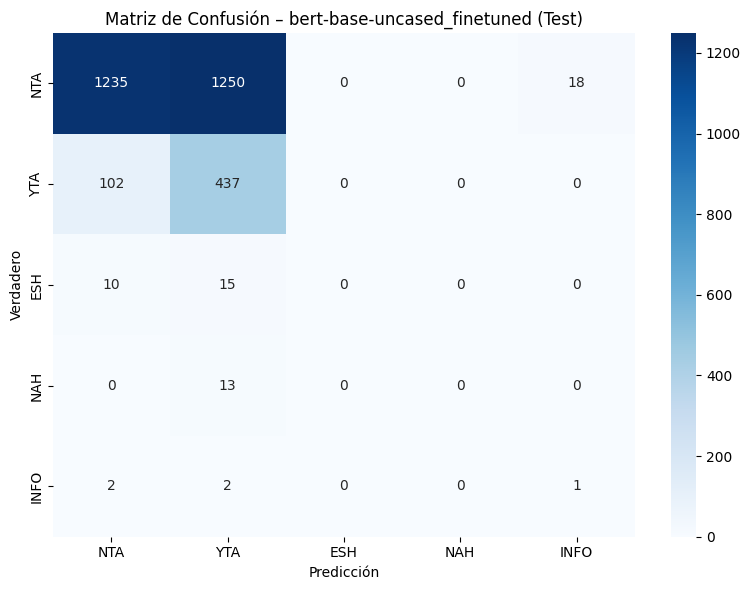

Resultados para bert-base-uncased_finetuned guardados.
Memoria GPU limpiada después de procesar bert-base-uncased.
--- Fin del ciclo para bert-base-uncased ---

▶ Iniciando Fine-tuning para: roberta-base
Experiment ID: roberta-base_finetuned
Cargando tokenizer: roberta-base...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizer 'roberta-base' cargado.
Creando datasets...
Tamaños de Datasets: Train=24672, Val=3084, Test=3085
Creando DataLoaders...
DataLoaders creados.
Cargando modelo preentrenado: roberta-base...
Modelo 'roberta-base' cargado en cuda.
Parámetros totales: 124,649,477
Optimizador AdamW configurado con LR=1e-05, Weight Decay=0.01.
Parámetros a optimizar: 124,649,477
Loss function: CrossEntropyLoss con class weights
Class weights (tensor): tensor([  0.2465,   1.1451,  24.9212,  46.5509, 129.8526])

Iniciando entrenamiento para roberta-base...
Configuración:
  - Modelo: roberta-base
  - Batch size: 32
  - Learning rate: 1e-05
  - Max epochs: 15
  - Patience: 3
  - Backbone: FINE-TUNING COMPLETO

Entrenando: roberta-base_finetuned
Épocas: 15 | Paciencia (basada en Val loss): 3
Loss: CrossEntropy (con Class Weights si se pasó en `loss_fn`)



Época 1/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

...

Época 6/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

Época  6: Train Loss: 0.8227 | Val Loss: 1.9468 | Val F1-Macro: 0.2973
🛑 Early stopping después de 6 épocas (Val loss no mejoró por 3 épocas).

📂 Cargando mejor modelo desde: saved_models_final/roberta_base_finetuned_best.pt (Val loss: 1.4452)

Evaluando en el conjunto de Test con el modelo seleccionado...


Evaluating roberta-base_finetuned (Test):   0%|          | 0/97 [00:00<?, ?it/s]


📋 roberta-base_finetuned (Test) — Accuracy: 0.6982 | Macro-F1: 0.2755 | Weighted-F1: 0.7240

Classification Report:
              precision    recall  f1-score   support

         NTA       0.89      0.72      0.80      2503
         YTA       0.33      0.65      0.44       539
         ESH       0.00      0.00      0.00        25
         NAH       0.00      0.00      0.00        13
        INFO       0.11      0.20      0.14         5

    accuracy                           0.70      3085
   macro avg       0.27      0.31      0.28      3085
weighted avg       0.78      0.70      0.72      3085



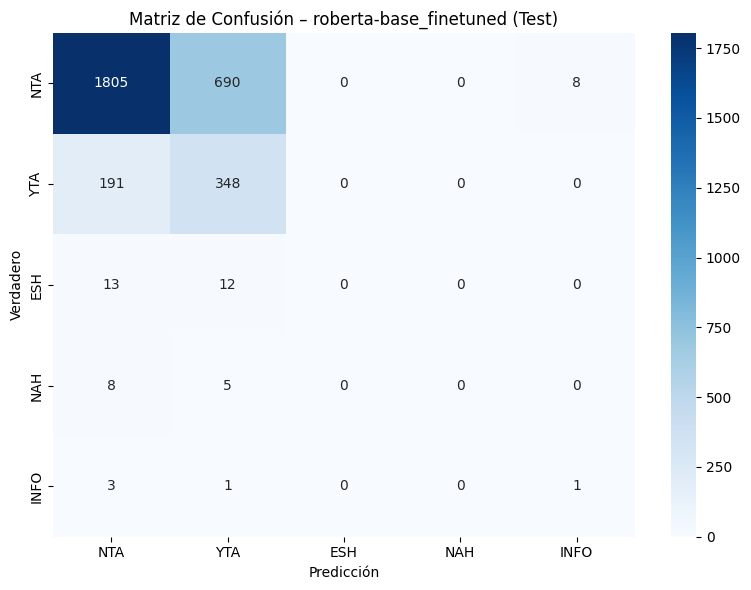

Resultados para roberta-base_finetuned guardados.
Memoria GPU limpiada después de procesar roberta-base.
--- Fin del ciclo para roberta-base ---

▶ Iniciando Fine-tuning para: xlm-roberta-base
Experiment ID: xlm-roberta-base_finetuned
Cargando tokenizer: xlm-roberta-base...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizer 'xlm-roberta-base' cargado.
Creando datasets...
Tamaños de Datasets: Train=24672, Val=3084, Test=3085
Creando DataLoaders...
DataLoaders creados.
Cargando modelo preentrenado: xlm-roberta-base...
Modelo 'xlm-roberta-base' cargado en cuda.
Parámetros totales: 278,047,493
Optimizador AdamW configurado con LR=1e-05, Weight Decay=0.01.
Parámetros a optimizar: 278,047,493
Loss function: CrossEntropyLoss con class weights
Class weights (tensor): tensor([  0.2465,   1.1451,  24.9212,  46.5509, 129.8526])

Iniciando entrenamiento para xlm-roberta-base...
Configuración:
  - Modelo: xlm-roberta-base
  - Batch size: 32
  - Learning rate: 1e-05
  - Max epochs: 15
  - Patience: 3
  - Backbone: FINE-TUNING COMPLETO

Entrenando: xlm-roberta-base_finetuned
Épocas: 15 | Paciencia (basada en Val loss): 3
Loss: CrossEntropy (con Class Weights si se pasó en `loss_fn`)



Época 1/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

...

Época 5/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

Época  5: Train Loss: 1.2821 | Val Loss: 1.5984 | Val F1-Macro: 0.2204
🛑 Early stopping después de 5 épocas (Val loss no mejoró por 3 épocas).

📂 Cargando mejor modelo desde: saved_models_final/xlm_roberta_base_finetuned_best.pt (Val loss: 1.4459)

Evaluando en el conjunto de Test con el modelo seleccionado...


Evaluating xlm-roberta-base_finetuned (Test):   0%|          | 0/97 [00:00<?, ?it/s]


📋 xlm-roberta-base_finetuned (Test) — Accuracy: 0.5909 | Macro-F1: 0.2164 | Weighted-F1: 0.6343

Classification Report:
              precision    recall  f1-score   support

         NTA       0.89      0.57      0.70      2503
         YTA       0.26      0.72      0.38       539
         ESH       0.00      0.00      0.00        25
         NAH       0.00      0.00      0.00        13
        INFO       0.00      0.00      0.00         5

    accuracy                           0.59      3085
   macro avg       0.23      0.26      0.22      3085
weighted avg       0.77      0.59      0.63      3085



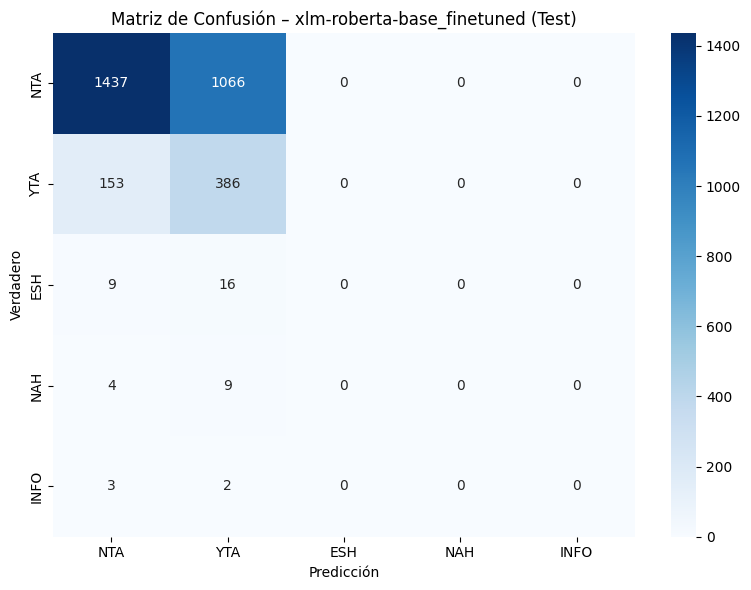

Resultados para xlm-roberta-base_finetuned guardados.
Memoria GPU limpiada después de procesar xlm-roberta-base.
--- Fin del ciclo para xlm-roberta-base ---

RESUMEN EXPERIMENTO 2: FINE-TUNING COMPLETO

Modelo: bert-base-uncased_finetuned
  Test accuracy: 0.5423
  Test macro_f1: 0.2224
  Test weighted_f1: 0.5881
  Checkpoint: saved_models_final/bert_base_uncased_finetuned_best.pt

Modelo: roberta-base_finetuned
  Test accuracy: 0.6982
  Test macro_f1: 0.2755
  Test weighted_f1: 0.7240
  Checkpoint: saved_models_final/roberta_base_finetuned_best.pt

Modelo: xlm-roberta-base_finetuned
  Test accuracy: 0.5909
  Test macro_f1: 0.2164
  Test weighted_f1: 0.6343
  Checkpoint: saved_models_final/xlm_roberta_base_finetuned_best.pt

🎉 Experimento 2 completado exitosamente!
Los resultados están en 'experiment_results', 'experiment_histories', 'experiment_model_paths'.


In [7]:

print(f"\n{'='*70}")
print("EXPERIMENTO 2: FINE-TUNING COMPLETO DE MODELOS BERT")
print(f"{'='*70}")

models_for_finetuning = [
    "bert-base-uncased",
    "roberta-base",
    "xlm-roberta-base"
]

for model_name_ft in models_for_finetuning:
    experiment_id_ft = f"{model_name_ft}_finetuned"
    print(f"\n▶ Iniciando Fine-tuning para: {model_name_ft}")
    print(f"Experiment ID: {experiment_id_ft}")

    # --- Tokenizer ---
    print(f"Cargando tokenizer: {model_name_ft}...")
    tokenizer_ft = AutoTokenizer.from_pretrained(model_name_ft)
    print(f"Tokenizer '{model_name_ft}' cargado.")

    # --- Datasets ---
    # Los datos X_train, y_train, etc., ya están definidos y preprocesados
    print("Creando datasets...")
    train_ds_ft = TextClassificationDataset(X_train, y_train, tokenizer_ft, MAX_SEQ_LEN)
    val_ds_ft = TextClassificationDataset(X_val, y_val, tokenizer_ft, MAX_SEQ_LEN)
    test_ds_ft = TextClassificationDataset(X_test, y_test, tokenizer_ft, MAX_SEQ_LEN)
    print(f"Tamaños de Datasets: Train={len(train_ds_ft)}, Val={len(val_ds_ft)}, Test={len(test_ds_ft)}")

    # --- DataLoaders ---
    print("Creando DataLoaders...")
    train_loader_ft = DataLoader(train_ds_ft, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader_ft = DataLoader(val_ds_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader_ft = DataLoader(test_ds_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print("DataLoaders creados.")

    # --- Modelo ---
    print(f"Cargando modelo preentrenado: {model_name_ft}...")
    config_ft = AutoConfig.from_pretrained(model_name_ft, num_labels=len(TARGET_LABELS))
    model_ft = AutoModelForSequenceClassification.from_pretrained(
        model_name_ft,
        config=config_ft,
        ignore_mismatched_sizes=True # Útil si modificas la cabeza de clasificación
    ).to(device)
    print(f"Modelo '{model_name_ft}' cargado en {device}.")
    print(f"Parámetros totales: {sum(p.numel() for p in model_ft.parameters()):,}")

    # --- Optimizador ---
    # Se optimizan todos los parámetros del modelo para fine-tuning completo
    optimizer_ft = AdamW(model_ft.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    print(f"Optimizador AdamW configurado con LR={LEARNING_RATE}, Weight Decay=0.01.")
    print(f"Parámetros a optimizar: {sum(p.numel() for p in model_ft.parameters() if p.requires_grad):,}")


    # --- Loss Function con class weights ---
    # Usar class_weights_tensor previamente calculado y movido al device
    loss_fn_ft = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
    # Alternativa: WeightedFocalLoss
    #loss_fn_ft = WeightedFocalLoss(class_weights_tensor.to(device), alpha=1, gamma=2)
    use_focal_loss_flag = False # Cambiar a True si se usa WeightedFocalLoss

    print(f"Loss function: CrossEntropyLoss con class weights") # Ajustar si se usa Focal Loss
    print(f"Class weights (tensor): {class_weights_tensor}")

    # --- Entrenamiento + Evaluación ---
    print(f"\nIniciando entrenamiento para {model_name_ft}...")
    print(f"Configuración:")
    print(f"  - Modelo: {model_name_ft}")
    print(f"  - Batch size: {BATCH_SIZE}")
    print(f"  - Learning rate: {LEARNING_RATE}")
    print(f"  - Max epochs: {MAX_EPOCHS}")
    print(f"  - Patience: {PATIENCE_EARLY_STOPPING}")
    print(f"  - Backbone: FINE-TUNING COMPLETO")

    model_ft_trained, history_ft, path_ft, metrics_ft = train_and_evaluate_model(
        model=model_ft,
        model_name=experiment_id_ft,
        train_loader=train_loader_ft,
        val_loader=val_loader_ft,
        test_loader=test_loader_ft,
        optimizer=optimizer_ft,
        loss_fn=loss_fn_ft,
        device=device,
        id2label_map=id2label,
        n_epochs=MAX_EPOCHS,
        patience=PATIENCE_EARLY_STOPPING,
        freeze_backbone=False,  # Asegurar que todos los pesos se ajusten
        use_focal_loss_print_only=use_focal_loss_flag    # Poner True si se elige WeightedFocalLoss arriba
    )

    # --- Guardar resultados ---
    experiment_results[experiment_id_ft] = metrics_ft
    experiment_histories[experiment_id_ft] = history_ft
    experiment_model_paths[experiment_id_ft] = path_ft
    print(f"Resultados para {experiment_id_ft} guardados.")
    

    # --- Limpiar memoria GPU para el siguiente modelo ---
    del model_ft, tokenizer_ft, train_ds_ft, val_ds_ft, test_ds_ft
    del train_loader_ft, val_loader_ft, test_loader_ft, optimizer_ft, loss_fn_ft
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    print(f"Memoria GPU limpiada después de procesar {model_name_ft}.")
    print(f"--- Fin del ciclo para {model_name_ft} ---")


print(f"\n{'='*70}")
print("RESUMEN EXPERIMENTO 2: FINE-TUNING COMPLETO")
print(f"{'='*70}")
for name, metrics in experiment_results.items():
    if "_finetuned" in name: # Mostrar solo resultados de este experimento
        print(f"\nModelo: {name}")
        if metrics: # Verificar que metrics no esté vacío
            for m, v in metrics.items():
                if isinstance(v, (int, float)): # Imprimir solo métricas numéricas
                    print(f"  Test {m}: {v:.4f}")
        else:
            print("  No se encontraron métricas para este modelo.")
        print(f"  Checkpoint: {experiment_model_paths.get(name, 'No guardado o error')}")

if device.type == 'cuda':
    torch.cuda.empty_cache()

print(f"\n🎉 Experimento 2 completado exitosamente!")
print("Los resultados están en 'experiment_results', 'experiment_histories', 'experiment_model_paths'.")

# 🔩 Bloque 4 · Modelos con Texto + Variables Numéricas  
En este bloque se:  

1. **Elige la mejor arquitectura base** del Bloque 3 (según macro-F1 de test).  
2. **Crea un modelo combinado** que concatena la salida `[CLS]` (o `pooler_output`) del
   transformador con las tres variables numéricas estandarizadas  
   `score`, `num_comments`, `text_length`.  
3. Entrena con *early-stopping*, guarda el **mejor checkpoint** y registra
   *train / val loss* + *val macro-F1*.  
4. Evalúa en test y guarda métricas para poder compararlas con los modelos
   solo-texto.


In [8]:

# ---------- EXPERIMENTO 3: MODELO COMBINADO (TEXTO + FEATURES NUMÉRICAS) ----------
print(f"\n{'='*70}")
print("EXPERIMENTO 3: MODELO COMBINADO (TEXTO + FEATURES NUMÉRICAS)")
print(f"{'='*70}")

# 1. Elegir el mejor backbone del Experimento 2
exp2_results_filtered = {k: v for k, v in experiment_results.items() if "_finetuned" in k and v} # Asegurar que v no sea None/vacío
best_base_model_name_exp3 = "roberta-base" # Fallback por si el Exp2 no corrió o no tuvo resultados

if not exp2_results_filtered:
    print("⚠️ No se encontraron resultados del Experimento 2. Usando 'bert-base-uncased' como fallback para Exp3.")
else:
    # Asegurarse de que 'macro_f1' existe en las métricas
    valid_exp2_results = {k: v for k, v in exp2_results_filtered.items() if isinstance(v, dict) and 'macro_f1' in v}
    if not valid_exp2_results:
        print("⚠️ Los resultados del Experimento 2 no contienen 'macro_f1'. Usando 'bert-base-uncased' como fallback.")
    else:
        best_experiment_id_exp3 = max(valid_exp2_results, key=lambda k: valid_exp2_results[k]['accuracy'])
        best_base_model_name_exp3 = best_experiment_id_exp3.replace("_finetuned", "")
        print(f"🏆 Mejor backbone del Experimento 2 (basado en Test): {best_base_model_name_exp3}")



EXPERIMENTO 3: MODELO COMBINADO (TEXTO + FEATURES NUMÉRICAS)
🏆 Mejor backbone del Experimento 2 (basado en Test): roberta-base


In [9]:
# 2. Definir la clase del modelo combinado
class TextPlusFeaturesClassifier(nn.Module):
    def __init__(self, base_model_name, num_numerical_features, num_labels, dropout_rate=0.1):
        super().__init__()
        # Cargar solo el cuerpo del transformador (sin la cabeza de clasificación preexistente)
        self.encoder = AutoModel.from_pretrained(base_model_name)
        encoder_hidden_size = self.encoder.config.hidden_size
        
        self.dropout = nn.Dropout(dropout_rate)
        # La capa de clasificación tomará la salida del encoder + features numéricas
        self.classifier = nn.Linear(encoder_hidden_size + num_numerical_features, num_labels)

    def forward(self, input_ids, attention_mask, numerical_features, token_type_ids=None, labels=None):
        # `labels` no se usa aquí, la pérdida se calcula externamente
        encoder_outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )
        
        # Usar pooler_output si está disponible y es adecuado, o el embedding [CLS]
        if hasattr(encoder_outputs, 'pooler_output') and encoder_outputs.pooler_output is not None:
            pooled_representation = encoder_outputs.pooler_output
        else:
            # Tomar el estado oculto del token [CLS] (primero en la secuencia)
            pooled_representation = encoder_outputs.last_hidden_state[:, 0]
            
        # Concatenar la representación del texto con las features numéricas
        combined_features = torch.cat([pooled_representation, numerical_features], dim=1)
        
        # Aplicar dropout antes de la capa de clasificación
        dropped_features = self.dropout(combined_features)
        logits = self.classifier(dropped_features)
        
        # Devolver un diccionario para compatibilidad con train_and_evaluate_model y evaluate_model
        return {'logits': logits}

# 3. Preparar Datasets y DataLoaders para el Experimento 3
print(f"\nCargando tokenizer para el modelo base: {best_base_model_name_exp3}")
tokenizer_exp3 = AutoTokenizer.from_pretrained(best_base_model_name_exp3)

# num_cols ya está definido globalmente: ['score', 'num_comments', 'text_length']
num_cols = ['score', 'num_comments', 'text_length']
print(f"Usando características numéricas: {num_cols}")

train_ds_exp3 = TextClassificationDataset(X_train, y_train, tokenizer_exp3, MAX_SEQ_LEN, num_feature_names=num_cols)
val_ds_exp3 = TextClassificationDataset(X_val, y_val, tokenizer_exp3, MAX_SEQ_LEN, num_feature_names=num_cols)
test_ds_exp3 = TextClassificationDataset(X_test, y_test, tokenizer_exp3, MAX_SEQ_LEN, num_feature_names=num_cols)

train_loader_exp3 = DataLoader(train_ds_exp3, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_exp3 = DataLoader(val_ds_exp3, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_exp3 = DataLoader(test_ds_exp3, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("Datasets y DataLoaders para Experimento 3 creados.")




Cargando tokenizer para el modelo base: roberta-base
Usando características numéricas: ['score', 'num_comments', 'text_length']
Datasets y DataLoaders para Experimento 3 creados.


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Iniciando entrenamiento para Experimento 3 (roberta-base_combined_features)...

Entrenando: roberta-base_combined_features
Épocas: 15 | Paciencia (basada en Val loss): 3
Loss: Focal (con Class Weights si se pasó en `loss_fn`)



Época 1/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

Época  1: Train Loss: 1.5238 | Val Loss: 1.4922 | Val F1-Macro: 0.2281
✅ Nuevo mejor Val loss: 1.4922 → Guardado en saved_models_final/roberta_base_combined_features_best.pt


...

Época 5/15 [Train]:   0%|          | 0/771 [00:00<?, ?it/s]

Validación:   0%|          | 0/97 [00:00<?, ?it/s]

Época  5: Train Loss: 1.0079 | Val Loss: 1.6554 | Val F1-Macro: 0.2554
🛑 Early stopping después de 5 épocas (Val loss no mejoró por 3 épocas).

📂 Cargando mejor modelo desde: saved_models_final/roberta_base_combined_features_best.pt (Val loss: 1.4553)

Evaluando en el conjunto de Test con el modelo seleccionado...


Evaluating roberta-base_combined_features (Test):   0%|          | 0/97 [00:00<?, ?it/s]


📋 roberta-base_combined_features (Test) — Accuracy: 0.6123 | Macro-F1: 0.2269 | Weighted-F1: 0.6528

Classification Report:
              precision    recall  f1-score   support

         NTA       0.92      0.58      0.71      2503
         YTA       0.29      0.79      0.42       539
         ESH       0.00      0.00      0.00        25
         NAH       0.00      0.00      0.00        13
        INFO       0.00      0.00      0.00         5

    accuracy                           0.61      3085
   macro avg       0.24      0.28      0.23      3085
weighted avg       0.80      0.61      0.65      3085



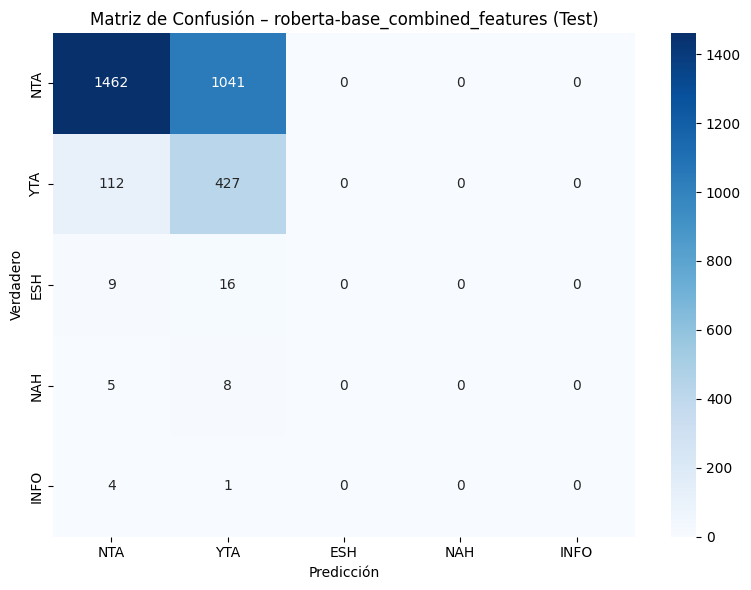

Resultados Experimento 3 para roberta-base_combined_features guardados.


In [14]:
from transformers import  AutoConfig, AutoModel, PreTrainedModel
experiment_id_exp3 = f"{best_base_model_name_exp3}_combined_features"
model_exp3 = TextPlusFeaturesClassifier(
    base_model_name=best_base_model_name_exp3,
    num_numerical_features=len(num_cols),
    num_labels=len(TARGET_LABELS)
).to(device)
optimizer_exp3 = AdamW(model_exp3.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
# Usar class_weights_tensor_on_device para WeightedFocalLoss
#loss_fn_exp3 = WeightedFocalLoss(class_weights_tensor, alpha=1, gamma=2)
loss_fn_exp3 = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

use_focal_print_exp3 = True
print(f"\nIniciando entrenamiento para Experimento 3 ({experiment_id_exp3})...")
model_trained_exp3, history_exp3, best_path_exp3, metrics_exp3 = train_and_evaluate_model(
    model=model_exp3, model_name=experiment_id_exp3,
    train_loader=train_loader_exp3, val_loader=val_loader_exp3, test_loader=test_loader_exp3,
    optimizer=optimizer_exp3, loss_fn=loss_fn_exp3, device=device, id2label_map=id2label,
    n_epochs=MAX_EPOCHS, patience=PATIENCE_EARLY_STOPPING,
    freeze_backbone=False, use_focal_loss_print_only=use_focal_print_exp3
)
experiment_results[experiment_id_exp3] = metrics_exp3
experiment_histories[experiment_id_exp3] = history_exp3
experiment_model_paths[experiment_id_exp3] = best_path_exp3
print(f"Resultados Experimento 3 para {experiment_id_exp3} guardados.")
if device.type == 'cuda': torch.cuda.empty_cache()



RESUMEN FINAL DE TODOS LOS EXPERIMENTOS

--- Resultados para: bert-base-uncased_frozen ---
  Mejor Checkpoint: saved_models_final/bert_base_uncased_frozen_best.pt
  Métricas en Test Set:
    Accuracy:    0.3712
    F1-Macro:    0.1477
    F1-Weighted: 0.3992


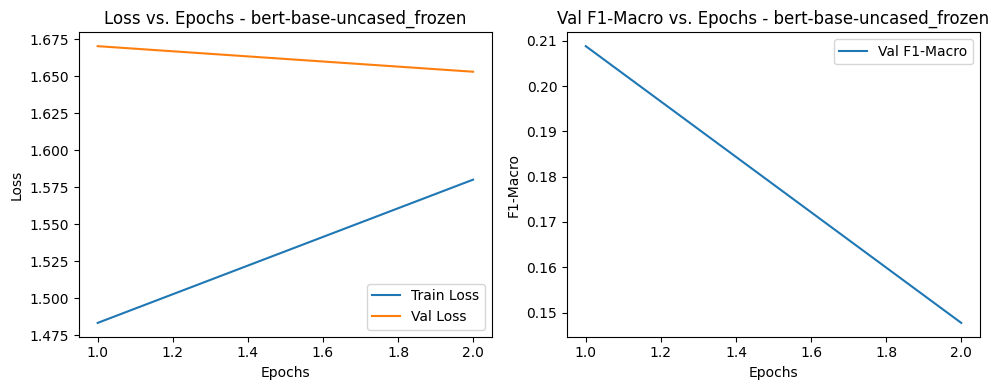


--- Resultados para: bert-base-uncased_finetuned ---
  Mejor Checkpoint: saved_models_final/bert_base_uncased_finetuned_best.pt
  Métricas en Test Set:
    Accuracy:    0.5423
    F1-Macro:    0.2224
    F1-Weighted: 0.5881


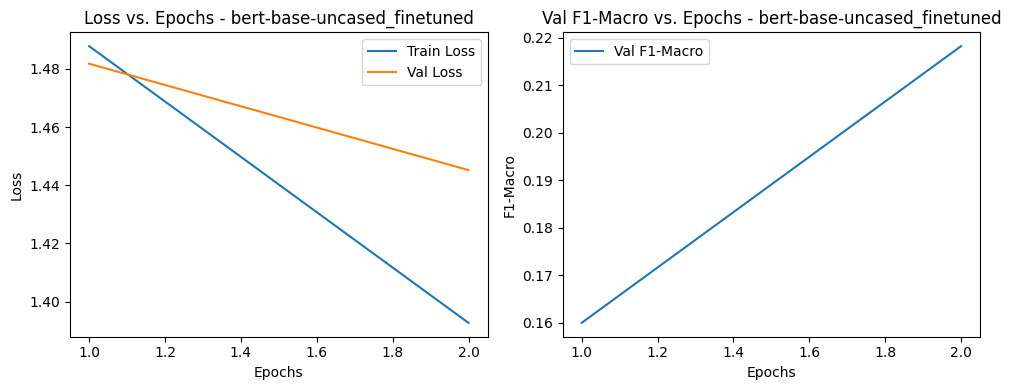


--- Resultados para: roberta-base_finetuned ---
  Mejor Checkpoint: saved_models_final/roberta_base_finetuned_best.pt
  Métricas en Test Set:
    Accuracy:    0.6982
    F1-Macro:    0.2755
    F1-Weighted: 0.7240


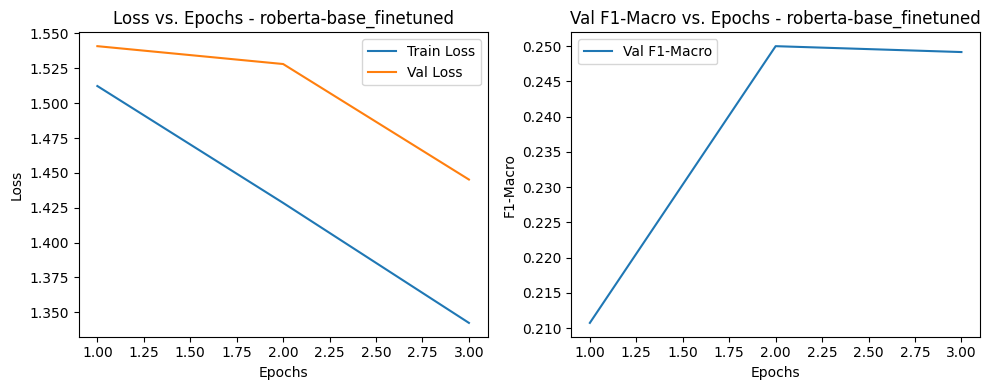


--- Resultados para: xlm-roberta-base_finetuned ---
  Mejor Checkpoint: saved_models_final/xlm_roberta_base_finetuned_best.pt
  Métricas en Test Set:
    Accuracy:    0.5909
    F1-Macro:    0.2164
    F1-Weighted: 0.6343


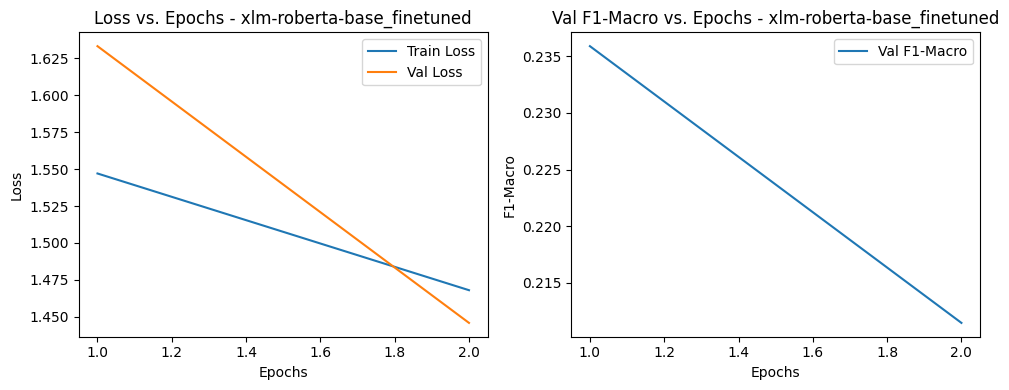


--- Resultados para: roberta-base_combined_features ---
  Mejor Checkpoint: saved_models_final/roberta_base_combined_features_best.pt
  Métricas en Test Set:
    Accuracy:    0.6123
    F1-Macro:    0.2269
    F1-Weighted: 0.6528


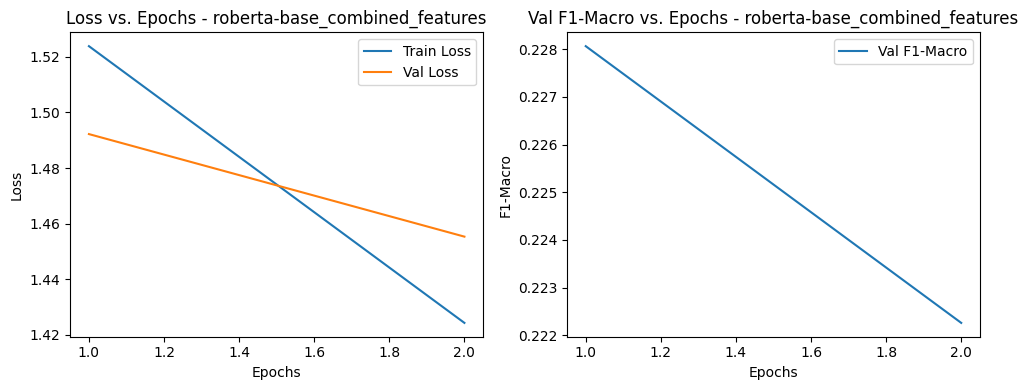


🎉 Todos los experimentos completados!


In [15]:
# ---------- RESUMEN FINAL DE TODOS LOS EXPERIMENTOS ----------
print(f"\n{'='*70}")
print("RESUMEN FINAL DE TODOS LOS EXPERIMENTOS")
print(f"{'='*70}")

for exp_id, metrics in experiment_results.items():
    print(f"\n--- Resultados para: {exp_id} ---")
    if metrics and isinstance(metrics, dict): # Verificar que metrics no sea None y sea un dict
        print(f"  Mejor Checkpoint: {experiment_model_paths.get(exp_id, 'No guardado o error')}")
        print(f"  Métricas en Test Set:")
        print(f"    Accuracy:    {metrics.get('accuracy', 'N/A'):.4f}")
        print(f"    F1-Macro:    {metrics.get('macro_f1', 'N/A'):.4f}")
        print(f"    F1-Weighted: {metrics.get('weighted_f1', 'N/A'):.4f}")
        
        # Opcional: Graficar historial de entrenamiento si está disponible
        history = experiment_histories.get(exp_id)
        if history and isinstance(history, dict) and history.get('train_loss') and history.get('val_loss'):
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.plot(history['epoch'], history['train_loss'], label='Train Loss')
            plt.plot(history['epoch'], history['val_loss'], label='Val Loss')
            plt.title(f'Loss vs. Epochs - {exp_id}')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()

            if history.get('val_macro_f1'):
                 plt.subplot(1, 2, 2)
                 plt.plot(history['epoch'], history['val_macro_f1'], label='Val F1-Macro')
                 plt.title(f'Val F1-Macro vs. Epochs - {exp_id}')
                 plt.xlabel('Epochs')
                 plt.ylabel('F1-Macro')
                 plt.legend()
            plt.tight_layout()
            plt.show()
    else:
        print(f"  No se encontraron métricas para {exp_id} o están en formato incorrecto.")

print(f"\n🎉 Todos los experimentos completados!")